In [1]:
# Loaded variable 'df' from URI: /home/sagemaker-user/smart-goals/raw-data/Store_Sales_Goal_Data.csv
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from snowflake.snowpark import Session
from snowflake.snowpark import functions as F

from smart_goals.utils.data_loaders import * 

In [2]:
session = Session.builder.getOrCreate()
session.use_database('DEV_DS')
session.use_schema('DBT_DWERNERSEXTON')

coh_na_txn_tbl = session.table('prd_crm.dlab.dlab_coh_na_txn')

In [3]:
analysis_start_date = '2023-01-01'
associate_tenure_start_date = '2020-01-01' # Associate IDs might not exist before this. 
goal_start_date = '2025-11-01'

In [4]:
associate_goal_hours_tbl = load_associate_goals_snowpark(session)
associate_goal_hours_tbl = associate_goal_hours_tbl.filter(F.col('BUSINESS_DATE') >= F.lit(goal_start_date))

/home/sagemaker-user/smart-goals/src/smart_goals/utils/data_loaders.py:33: DtypeWarning: Columns (8,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, parse_dates=['Business_Date'], dtype={'Store_Num': str, 'Employee_Num': str})


In [5]:
associate_daily_sales_hourly_dlabs_tbl =  (coh_na_txn_tbl
    .filter((F.nvl(F.col('SALES_ASSOCIATE'), F.lit('999999999')) < F.lit('999900000')) & (F.col('TXN_DATETIME') >= F.lit(analysis_start_date)))
    .with_column('TXN_DATEHOUR', F.trunc(F.col('TXN_DATETIME').cast('timestamp'), F.lit('HOUR'))) \
    .with_column('USD_ITEM_GROSS_AMT', F.when(F.col('SALE_CREDIT_CODE') == '1' , F.col('USD_ITEM_NET_AMT')).otherwise(0))
    .group_by('TXN_DATE', 'TXN_DATEHOUR', 'STORE_NBR', 'SALES_ASSOCIATE').agg(F.sum('USD_ITEM_NET_AMT').alias('NET_SALES_AMOUNT_DLABS'), 
                                                                              F.sum('USD_ITEM_GROSS_AMT').alias('GROSS_SALES_AMOUNT_DLABS'))
    .rename({'TXN_DATE': 'BUSINESS_DATE', 'STORE_NBR': 'STORE_NUMBER'})
)

associate_daily_sales_dlabs_tbl = (associate_daily_sales_hourly_dlabs_tbl
    .group_by('BUSINESS_DATE', 'STORE_NUMBER', 'SALES_ASSOCIATE').agg(F.sum('NET_SALES_AMOUNT_DLABS').alias('NET_SALES_AMOUNT_DLABS'), F.sum('GROSS_SALES_AMOUNT_DLABS').alias('GROSS_SALES_AMOUNT_DLABS'))   
)

In [6]:
associate_daily_sales_dlab_with_hours_tbl = (associate_daily_sales_dlabs_tbl
                                  .join(associate_goal_hours_tbl, using_columns = ['BUSINESS_DATE', 'STORE_NUMBER', 'SALES_ASSOCIATE'], how='left')
)

In [7]:
associate_daily_sales_dlab_with_hours_tbl.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"BUSINESS_DATE"  |"STORE_NUMBER"  |"SALES_ASSOCIATE"  |"NET_SALES_AMOUNT_DLABS"  |"GROSS_SALES_AMOUNT_DLABS"  |"FINANCE_TEAM_GOAL"  |"STORE_MANAGER_GOAL"  |"LEGION_SCHEDULED_HOURS"  |"GOALS_SCHEDULED_HOURS"  |"GOAL"   |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2024-01-04       |6100            |468592             |1644.83                   |1824.23                     |NULL                 |NULL                  |NULL                      |NULL                     |NULL     |
|2024-06-23       |5142            |902736             |7629.46                   |7751.24                     |NULL

Validate that our sales in DLABS are matching what we see in Zipline

In [8]:
associate_daily_sales_zipline_tbl = load_associate_daily_sales_snowpark(session)
associate_daily_sales_zipline_tbl = associate_daily_sales_zipline_tbl.rename({'NET_SALES_AMOUNT': 'NET_SALES_AMOUNT_ZIPLINE'})


In [9]:
associate_daily_sales_zipline_tbl.show()

-----------------------------------------------------------------------------------------
|"STORE_NUMBER"  |"BUSINESS_DATE"      |"SALES_ASSOCIATE"  |"NET_SALES_AMOUNT_ZIPLINE"  |
-----------------------------------------------------------------------------------------
|1100            |2025-09-26 00:00:00  |457121             |1330.0                      |
|1100            |2025-09-26 00:00:00  |532013             |383.5                       |
|1100            |2025-09-26 00:00:00  |558097             |1835.0                      |
|1100            |2025-09-26 00:00:00  |560309             |1070.0                      |
|1100            |2025-09-26 00:00:00  |742743             |2515.5                      |
|1100            |2025-09-26 00:00:00  |749077             |1700.0                      |
|1100            |2025-09-26 00:00:00  |999911000          |426.0                       |
|1100            |2025-09-28 00:00:00  |457121             |2640.5                      |
|1100     

In [10]:
associate_sales_hours_all_tbl = (associate_daily_sales_dlab_with_hours_tbl
                                 .join(associate_daily_sales_zipline_tbl, using_columns = ['BUSINESS_DATE', 'STORE_NUMBER', 'SALES_ASSOCIATE'], how='left'))
associate_sales_hours_all_tbl.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"BUSINESS_DATE"  |"STORE_NUMBER"  |"SALES_ASSOCIATE"  |"NET_SALES_AMOUNT_DLABS"  |"GROSS_SALES_AMOUNT_DLABS"  |"FINANCE_TEAM_GOAL"  |"STORE_MANAGER_GOAL"  |"LEGION_SCHEDULED_HOURS"  |"GOALS_SCHEDULED_HOURS"  |"GOAL"  |"NET_SALES_AMOUNT_ZIPLINE"  |
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2023-07-02       |3819            |479549             |5118.69                   |5279.34                     |NULL                 |NULL                  |NULL                      |NULL                     |NULL    |NULL                        |
|202

There are some minor differences in what we get in Dlabs and what is in Zipline but its not major, this suggests we can use the dlabs data for historical calculations. 

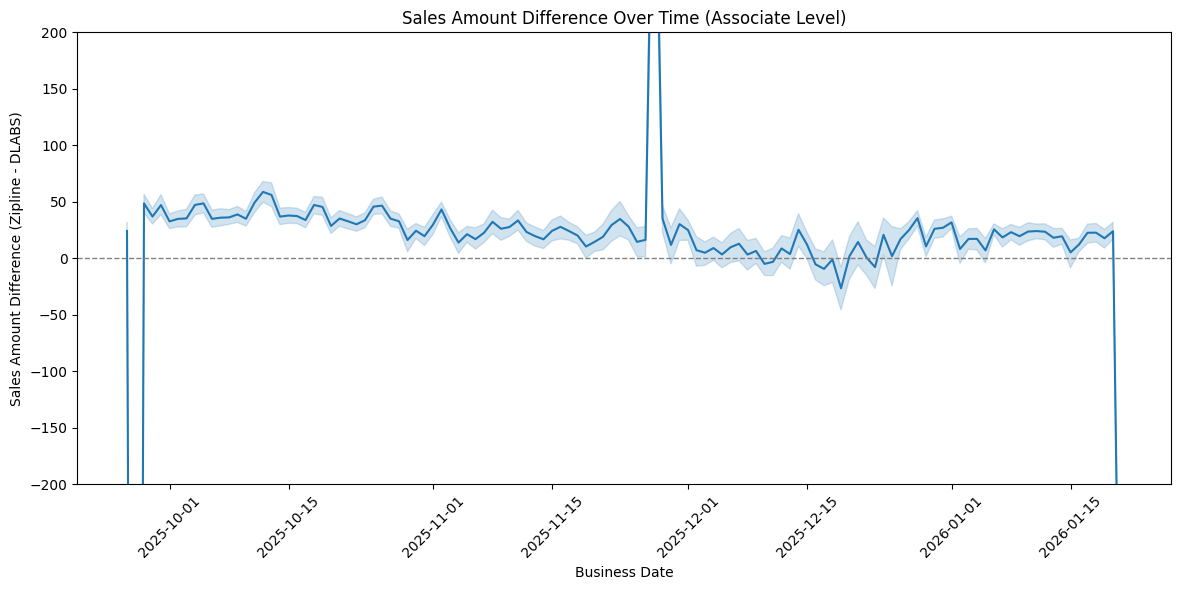

In [11]:
# Plot the difference in sales amounts between Zipline and DLABS Sales 
# Calculate the difference and convert to pandas for plotting
associate_sales_diff_df = (associate_sales_hours_all_tbl
                           .filter(F.col('NET_SALES_AMOUNT_ZIPLINE').is_not_null() & F.col('NET_SALES_AMOUNT_DLABS').is_not_null())
                           .with_column('SALES_AMOUNT_DIFF', F.col('NET_SALES_AMOUNT_ZIPLINE') - F.col('NET_SALES_AMOUNT_DLABS'))
).to_pandas()

# Plot the differences by dates
plt.figure(figsize=(12, 6))
sns.lineplot(data=associate_sales_diff_df, x='BUSINESS_DATE', y='SALES_AMOUNT_DIFF')
plt.axhline(y=0, color='grey', linestyle='--', linewidth=1)
plt.title('Sales Amount Difference Over Time (Associate Level)')
plt.xlabel('Business Date')
plt.ylabel('Sales Amount Difference (Zipline - DLABS)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(-200, 200)  # Zoom into y-axis range from -2000 to 2000
plt.show()

1. What is the difference between Associate Sales Goal Data and Associate Goal and Hours Data? 

TODO: Check to see if there were any associates or stores dropped in either table as a result of this join

## Associate Tenure

In [12]:
# Calculate the Number of Selling Days per Associate, This isnt quite right as it's not distinct but the edge case would be working in 2 stores on the same day. 
associate_tenure_days = coh_na_txn_tbl.group_by('SALES_ASSOCIATE').agg(F.min('TXN_DATE').alias('FIRST_SELLING_DAY'))

In [13]:
# There are lots of 9999##### Associate IDS and a Null - these should be filtered out I think. They don't appear in the scheduled employee data. 
associate_tenure_days.order_by('FIRST_SELLING_DAY').show(10)

-------------------------------------------
|"SALES_ASSOCIATE"  |"FIRST_SELLING_DAY"  |
-------------------------------------------
|NULL               |2002-01-01           |
|073012             |2019-08-04           |
|987565             |2019-08-04           |
|430506             |2019-08-04           |
|999951620          |2019-08-04           |
|411145             |2019-08-04           |
|999973000          |2019-08-04           |
|424962             |2019-08-04           |
|063598             |2019-08-05           |
|999940090          |2019-08-06           |
-------------------------------------------



In [14]:
complete_tenure_days_tbl = associate_tenure_days.filter(F.col('FIRST_SELLING_DAY').is_not_null() & (F.col('FIRST_SELLING_DAY') >= F.lit(associate_tenure_start_date)))

## Associate Schedules

### Legion Associate Daily Schedules

In [15]:
associate_daily_schedule_tbl = load_associate_daily_schedule_snowpark(session, deduplicate = True)


/home/sagemaker-user/smart-goals/.venv/lib/python3.12/site-packages/snowflake/snowpark/session.py:3478: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, _, _, ci_output = write_pandas(


There was considerable duplicated data in here, I've removed it by looking at the modified date but in most cases it looked like they are identitical. 

In [16]:
## This code was used to identify and remove duplicates in the associate_daily_schedule_tbl
# associate_daily_schedule_tbl.show()
# # Convert to pandas to check for duplicates
# associate_daily_schedule_df_check = associate_daily_schedule_tbl.to_pandas()

# # Check for duplicates on the combination of BUSINESS_DATE, SALES_ASSOCIATE, STORE_NUMBER
# duplicates = associate_daily_schedule_df_check.groupby(['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER']).size()
# duplicate_count = (duplicates > 1).sum()
# total_duplicates = duplicates[duplicates > 1].sum() - duplicate_count

# print(f"Number of duplicate combinations: {duplicate_count}")
# print(f"Total duplicate rows: {total_duplicates}")

# if duplicate_count > 0:
#     # Create a dataframe with only the duplicate rows
#     duplicate_mask = associate_daily_schedule_df_check.duplicated(subset=['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER'], keep=False)
#     duplicates_only_df = associate_daily_schedule_df_check[duplicate_mask].sort_values(['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER'])
    
#     print(f"\nTotal rows in duplicates table: {len(duplicates_only_df)}")
#     print("\nFirst 20 duplicate rows:")
#     print(duplicates_only_df.head(20))


In [17]:
associate_daily_schedule_tbl = (associate_daily_schedule_tbl
        .select('STORE_NUMBER', 'SALES_ASSOCIATE', 'BUSINESS_DATE', 'SHIFT_TYPE', 
                F.hour(F.col('SHIFT_START').cast('timestamp')).alias('SHIFT_START_HOUR'), 
                F.hour(F.col('SHIFT_END').cast('timestamp')).alias('SHIFT_END_HOUR'))
)

### Store Hours

In [18]:
store_hours_tbl = load_store_hours_snowpark(session)
store_hours_simplified = store_hours_tbl.select('STORE_NUMBER', 'BUSINESS_DATE', F.hour(F.col('OPEN_TIME').cast('timestamp')).alias('OPEN_HOUR'), F.hour(F.col('CLOSE_TIME').cast('timestamp')).alias('CLOSE_HOUR')).group_by(F.col('STORE_NUMBER')).agg(F.mode('OPEN_HOUR').alias('OPEN_HOUR'), F.mode('CLOSE_HOUR').alias('CLOSE_HOUR'))
# IF a store in the store_hours_simplied has 0 as open or close hours, replace it with the global average
store_hours_simplified = store_hours_simplified.with_column('OPEN_HOUR', F.when(store_hours_simplified['OPEN_HOUR'] == 0, 10).otherwise(store_hours_simplified['OPEN_HOUR'])) \
    .with_column('CLOSE_HOUR', F.when(store_hours_simplified['CLOSE_HOUR'] == 0, 20).otherwise(store_hours_simplified['CLOSE_HOUR']))
store_hours_simplified.show()

/home/sagemaker-user/smart-goals/.venv/lib/python3.12/site-packages/snowflake/snowpark/session.py:3478: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, _, _, ci_output = write_pandas(


-----------------------------------------------
|"STORE_NUMBER"  |"OPEN_HOUR"  |"CLOSE_HOUR"  |
-----------------------------------------------
|1202            |10           |20            |
|1243            |10           |21            |
|1302            |10           |20            |
|1651            |10           |21            |
|1654            |10           |21            |
|2460            |11           |20            |
|2554            |10           |21            |
|1220            |10           |20            |
|2451            |10           |21            |
|2704            |10           |21            |
-----------------------------------------------



### Associate Schedules Join Store Hours

In [19]:
associate_daily_schedule_tbl = (associate_daily_schedule_tbl
                                .join(store_hours_simplified, using_columns = ['STORE_NUMBER'], how='left')
                                .with_column('HOURS_SINCE_OPEN', F.when(F.col('SHIFT_START_HOUR') >= F.col('OPEN_HOUR'), F.col('SHIFT_START_HOUR') - F.col('OPEN_HOUR')).otherwise(0))
                                .with_column('HOURS_SINCE_OPEN_CORRECTED', F.when(F.col('HOURS_SINCE_OPEN') >= 0, F.col('HOURS_SINCE_OPEN')).otherwise(0))
)

associate_daily_schedule_tbl = associate_daily_schedule_tbl.with_column(
    'TIME_OF_DAY',
    F.when(F.col('HOURS_SINCE_OPEN_CORRECTED') <= 3, F.lit('Morning'))
     .when(F.col('HOURS_SINCE_OPEN_CORRECTED') <= 6, F.lit('Midday'))
     .when(F.col('HOURS_SINCE_OPEN_CORRECTED') <= 9, F.lit('Evening'))
     .otherwise(F.lit('Closing'))
)

In [20]:
# Check for duplicates on the combination of BUSINESS_DATE, SALES_ASSOCIATE, STORE_NUMBER
associate_daily_schedule_df = associate_daily_schedule_tbl.to_pandas()
duplicates = associate_daily_schedule_df.groupby(['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER']).size()
duplicate_count = (duplicates > 1).sum()
total_duplicates = duplicates[duplicates > 1].sum() - duplicate_count

print(f"Number of duplicate combinations: {duplicate_count}")
print(f"Total duplicate rows: {total_duplicates}")

if duplicate_count > 0:
    print("\nSample of duplicates:")
    duplicate_keys = duplicates[duplicates > 1].head(10)
    print(duplicate_keys)
    
    # Create a dataframe with the duplicate rows for inspection
    duplicate_mask = associate_daily_schedule_df.duplicated(subset=['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER'], keep=False)
    duplicates_df = associate_daily_schedule_df[duplicate_mask].sort_values(['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER'])
    
    print(f"\nTotal rows in duplicates dataframe: {len(duplicates_df)}")
    print("\nFirst 20 duplicate rows:")
    print(duplicates_df.head(20))

Number of duplicate combinations: 0
Total duplicate rows: 0


It looks like Shift Data before November 2025 atleast is a bit corrupted as many are just defaulted to 15:00:00. I'd need this data to go back further in time to calculate the performance of each associate over time. 

Pre Filtering: 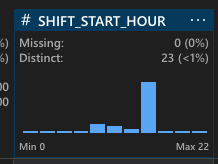
Post Filtering: 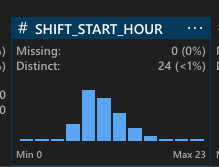

In [21]:
associate_daily_schedule_df.head()

,STORE_NUMBER,SALES_ASSOCIATE,BUSINESS_DATE,SHIFT_TYPE,SHIFT_START_HOUR,SHIFT_END_HOUR,OPEN_HOUR,CLOSE_HOUR,HOURS_SINCE_OPEN,HOURS_SINCE_OPEN_CORRECTED,TIME_OF_DAY
0,7503,755496,2026-01-31,R,10,15,9.0,20.0,1,1,Morning
1,5056,557965,2026-01-27,R,15,22,10.0,21.0,5,5,Midday
2,5055,754042,2026-01-27,R,16,23,10.0,21.0,6,6,Midday
3,5055,755163,2026-01-27,R,9,17,10.0,21.0,0,0,Morning
4,5055,756502,2026-01-27,R,10,18,10.0,21.0,0,0,Morning


In [22]:
associate_daily_schedule_filtered_tbl = (
    associate_daily_schedule_tbl.filter(F.col('BUSINESS_DATE') > F.lit(goal_start_date))
)

## Complete Dataset

Because of the Censored Data (i.e. no Associate Date before 2019), I am limiting to only Associates that we have a full history of (2020 forward). While this impacts our understanding of extremely long tenure, it reduces noise and still gives us a lot of information about our current associates. 

In [23]:
associate_goals_tbl = (associate_sales_hours_all_tbl
                      .join(associate_daily_schedule_filtered_tbl, using_columns = ['BUSINESS_DATE', 'STORE_NUMBER', 'SALES_ASSOCIATE'], how='left')
                      # .join(associate_tenure_days_tbl, using_columns=['SALES_ASSOCIATE'], how='left')
                      .join(complete_tenure_days_tbl, using_columns=['SALES_ASSOCIATE'], how='inner')
)

In [24]:
# In cases where associates work past close, their goals can be too long. Also, I have 
# shift data and sometimes don't have Goal data. 
associate_goals_tbl.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"SALES_ASSOCIATE"  |"BUSINESS_DATE"  |"STORE_NUMBER"  |"NET_SALES_AMOUNT_DLABS"  |"GROSS_SALES_AMOUNT_DLABS"  |"FINANCE_TEAM_GOAL"  |"STORE_MANAGER_GOAL"  |"LEGION_SCHEDULED_HOURS"  |"GOALS_SCHEDULED_HOURS"  |"GOAL"  |"NET_SALES_AMOUNT_ZIPLINE"  |"SHIFT_TYPE"  |"SHIFT_START_HOUR"  |"SHIFT_END_HOUR"  |"OPEN_HOUR"  |"CLOSE_HOUR"  |"HOURS_SINCE_OPEN"  |"HOURS_SINCE_OPEN_CORRECTED"  |"TIME_OF_DAY"  |"FIRST_SELLING_DAY"  |
----------------------------------------------------------------------------------------------------------------------------------------------------------

In [25]:

associate_goals_tbl = (
    associate_goals_tbl
)

Notes: My initial approach of using a Time Of Day for the shift isn't working as I was assigning based on the initial hour but shifts start at any point during the day and cover a wide range of the day - i.e. a Morning shift might start at 12 and extend well into the evening. Instead, I think I need to use a calculation like: 
% Store Sales upto Shift End - % Store Sales upto Shift Start - that give the % of Store Sales that associate would be responsible for - this then would need to be divided by the day. 



There are cases of extreme values in the Goal Hours that don't correspond to the length of the possible shift. This correction addresses three scenarios:

1. **Goals exceeding shift duration**: When `GOALS_SCHEDULED_HOURS` is longer than the actual shift length
2. **Goals exceeding store hours**: When `GOALS_SCHEDULED_HOURS` exceeds the maximum possible working hours (store open to close)
3. **Overnight shifts**: Properly calculating shift duration when shifts cross midnight

The correction uses the minimum of:
- The original `GOALS_SCHEDULED_HOURS`
- The calculated `SHIFT_DURATION` 
- The `MAX_POSSIBLE_HOURS` (store operating hours)

This ensures goal hours are realistic and aligned with actual working time available.

In [26]:
associate_goals_tbl.select('BUSINESS_DATE', 'STORE_NUMBER', 'SALES_ASSOCIATE', 'SHIFT_TYPE', 'SHIFT_START_HOUR', 'SHIFT_END_HOUR', 'OPEN_HOUR', 'CLOSE_HOUR', 'GOALS_SCHEDULED_HOURS').order_by(F.desc('GOALS_SCHEDULED_HOURS')).show(20)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"BUSINESS_DATE"  |"STORE_NUMBER"  |"SALES_ASSOCIATE"  |"SHIFT_TYPE"  |"SHIFT_START_HOUR"  |"SHIFT_END_HOUR"  |"OPEN_HOUR"  |"CLOSE_HOUR"  |"GOALS_SCHEDULED_HOURS"  |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2025-12-08       |2579            |743087             |R             |9                   |17                |10           |20            |31.5                     |
|2025-12-23       |2472            |733169             |R             |9                   |15                |10           |21            |30.0                     |
|2025-12-24       |4052            |731020             |R             |7                   |16                |10           |20            |23.5                     

In [27]:
store_mstr = load_store_data(session)

/home/sagemaker-user/smart-goals/.venv/lib/python3.12/site-packages/snowflake/snowpark/session.py:3478: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  success, _, _, ci_output = write_pandas(


In [28]:
associate_goals_tbl = associate_goals_tbl.join(store_mstr, using_columns = ['STORE_NUMBER'], how='left')

# Calculate additional date features and tenure days, convert to pandas
associate_goals_tbl = (associate_goals_tbl
    # .filter(F.col('BUSINESS_DATE') >= F.lit(goal_start_date))
    .order_by(['STORE_NUMBER', 'BUSINESS_DATE', 'SALES_ASSOCIATE', 'TIME_OF_DAY'])
    .with_column('MONTH', F.month('BUSINESS_DATE'))
    .with_column('DAY_OF_WEEK', F.dayofweek('BUSINESS_DATE'))
    .with_column('WEEK_OF_YEAR', F.weekofyear('BUSINESS_DATE'))
    .with_column('TENURE_MONTHS', F.datediff('MONTH', F.col('FIRST_SELLING_DAY'), F.col('BUSINESS_DATE')))
    # Handle overnight shifts where SHIFT_END_HOUR < SHIFT_START_HOUR
    .with_column('SHIFT_DURATION', 
        F.when(F.col('SHIFT_END_HOUR') < F.col('SHIFT_START_HOUR'), 
               24 - F.col('SHIFT_START_HOUR') + F.col('SHIFT_END_HOUR'))
        .otherwise(F.col('SHIFT_END_HOUR') - F.col('SHIFT_START_HOUR')))
    # Calculate maximum possible hours (from shift start to store close, considering overnight)
    .with_column('MAX_POSSIBLE_HOURS', F.col('CLOSE_HOUR') - F.col('OPEN_HOUR'))
    # There are cases where the GOALS_SCHEDULED_HOURS is longer than the shift duration or max possible hours
    # which shouldn't be possible. This could be due to incorrect goal data 
    # or associates working past close. We should investigate these cases further.
    # .with_column('TIME_OF_DAY', F.when(F.col('SHIFT_END_HOUR') >= F.col('CLOSE_HOUR'), F.lit('Closing')).otherwise(F.col('TIME_OF_DAY')))
    .with_column('GOALS_SCHEDULED_HOURS_CORRECTED', 
        F.when(F.col('GOALS_SCHEDULED_HOURS') > (F.col('SHIFT_DURATION')), F.col('SHIFT_DURATION'))
        .when(F.col('GOALS_SCHEDULED_HOURS') > (F.col('MAX_POSSIBLE_HOURS')), F.col('MAX_POSSIBLE_HOURS'))
               .otherwise(F.col('GOALS_SCHEDULED_HOURS')))
)

associate_goals_df = (
    associate_goals_tbl
).to_pandas()

associate_goals_filtered_df

In [ ]:
# Check for duplicates on the combination of BUSINESS_DATE, SALES_ASSOCIATE, STORE_NUMBER
duplicates = associate_goals_df.groupby(['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER']).size()
duplicate_count = (duplicates > 1).sum()
total_duplicates = duplicates[duplicates > 1].sum() - duplicate_count

print(f"Number of duplicate combinations: {duplicate_count}")
print(f"Total duplicate rows: {total_duplicates}")

if duplicate_count > 0:
    print("\nSample of duplicates:")
    duplicate_keys = duplicates[duplicates > 1].head(10)
    print(duplicate_keys)
    
    # Create a dataframe with the duplicate rows for inspection
    duplicate_mask = associate_goals_df.duplicated(subset=['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER'], keep=False)
    duplicates_df = associate_goals_df[duplicate_mask].sort_values(['BUSINESS_DATE', 'SALES_ASSOCIATE', 'STORE_NUMBER'])
    
    print(f"\nTotal rows in duplicates dataframe: {len(duplicates_df)}")
    print("\nFirst 20 duplicate rows:")
    print(duplicates_df.head(20))

Number of duplicate combinations: 0
Total duplicate rows: 0


In [29]:
associate_goals_df.to_feather('/home/sagemaker-user/smart-goals/data/associate_goals_df.feather')